# Trustworthy Stock Forecaster
### A Probabilistic Forecasting & Calibration Toolkit

**AAI/CPE/EE 551 — Engineering Python | Course Project — Team 2**

| Name | Email | CWID |
|---|---|---|
| Olin Dsouza | odsouza1@stevens.edu | 20033076 |
| Yogesh Patil | ypatel33@stevens.edu | 20032007 |
| Kevin Gwinn | kgwinn@stevens.edu | 20017424 |

---

## The problem

Most stock-prediction tools output a single predicted value and say nothing about how much
that value can be trusted. A forecast without a measure of uncertainty is unsafe to act on,
and models that look reliable in calm markets frequently become **over-confident during
volatile periods**. This project treats the *trustworthiness* of a forecast as the core
engineering problem.

## What this notebook does

1. **Load & clean** historical daily price data from the committed CSV files (`data_loader.py`).
2. **Compute log-returns** and label every day as a **calm** or **volatile** regime using
   rolling volatility (`data_loader.py`), organizing the assets into a **Portfolio** of
   **StockAssets** objects (`portfolio.py`).
3. **Generate probabilistic forecasts** — predictive intervals, not point estimates — with a
   random-walk baseline and a RiskMetrics **EWMA** volatility model (`forecasters.py`).
4. **Run a rolling-window backtest** that re-fits each model every month, exactly as it would
   be used in real time (`backtest.py`).
5. **Measure calibration** — CRPS and empirical interval coverage — **separately per regime**,
   and draw reliability diagrams that reveal when a model's stated confidence can actually be
   believed (`calibration.py`).

**Data:** daily OHLCV CSVs committed in `data/` (AAPL, MSFT, JPM — about 4 years each),
originally retrieved with `data_updater.py` from the Alpha Vantage free daily API and stored
in the repository so the whole analysis is reproducible offline.

## 0 · Imports — all logic lives in the project's `.py` modules

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd

# project modules (each one also runs standalone via its __main__ guard)
from data_loader import (
    load_daily_data,
    compute_log_returns,
    rolling_volatility,
    label_regime,
)
from portfolio import StockAssets, Portfolio
from forecasters import RandomWalkForecaster, EWMAForecaster
from backtest import run_backtest, summarize_by_regime, reports_to_frame
from calibration import plot_reliability_diagram

OUTPUT_DIR = "output"                      # where reports and figures are written
os.makedirs(OUTPUT_DIR, exist_ok=True)

SYMBOLS = ["AAPL", "MSFT", "JPM"]          # tickers committed in data/ (mutable list)
DATA_FILES = {s: os.path.join("data", f"{s.lower()}_sample.csv") for s in SYMBOLS}
print("Environment ready. Symbols:", SYMBOLS)

Environment ready. Symbols: ['AAPL', 'MSFT', 'JPM']


## 1 · Data loading, cleaning & exception handling

`load_daily_data()` validates the file and its contents. First we demonstrate both required
exception scenarios being caught gracefully, then build the `Portfolio` **composed of**
`StockAssets` objects (the composition class relationship).

In [2]:
# exception scenario 1: a missing data file raises FileNotFoundError
try:
    load_daily_data(os.path.join("data", "tsla_sample.csv"))
except FileNotFoundError as error:
    print(f"Caught FileNotFoundError -> {error}")

# exception scenario 2: too little data for the rolling window raises ValueError
try:
    tiny_frame = pd.DataFrame({"Close": [100.0, 101.0, 99.5]})
    label_regime(compute_log_returns(tiny_frame), window=20)
except ValueError as error:
    print(f"Caught ValueError        -> {error}")

# exception scenario 3: adding a non-StockAssets object raises TypeError
try:
    Portfolio(name="Broken").add_asset("just a string")
except TypeError as error:
    print(f"Caught TypeError         -> {error}")

Caught FileNotFoundError -> Price data file not found: data/tsla_sample.csv
Caught ValueError        -> unable to compute rolling volatility window
Caught TypeError         -> Portfolio only accepts StockAssets objects


In [3]:
# build the portfolio: Portfolio is COMPOSED OF StockAssets objects
portfolio = Portfolio(name="Team 2 Portfolio")
for symbol in SYMBOLS:                       # loop: one asset per symbol
    portfolio.add_asset(StockAssets.from_csv(symbol, DATA_FILES[symbol]))

print(portfolio)                             # __str__ operator overload
print("\nNumber of assets (len(portfolio)):", len(portfolio))   # __len__ overload

Portfolio 'Team 2 Portfolio' (3 assets):
AAPL: 1000 days, mean_return=-0.000872, vol=0.037857
MSFT: 1000 days, mean_return=0.001343, vol=0.033299
JPM: 1000 days, mean_return=-0.000883, vol=0.042397

Number of assets (len(portfolio)): 3


In [4]:
# more operator overloading: __add__ merges portfolios, __eq__ compares them
tech = Portfolio(name="Tech")
tech.add_asset(portfolio.get_asset("AAPL"))
tech.add_asset(portfolio.get_asset("MSFT"))

banks = Portfolio(name="Banks")
banks.add_asset(portfolio.get_asset("JPM"))

merged = tech + banks                        # __add__ overload
print("merged == portfolio ?", merged == portfolio)   # __eq__ overload -> True
print("tech   == banks     ?", tech == banks)         # -> False

merged == portfolio ? True
tech   == banks     ? False


## 2 · Log-returns & volatility-regime labeling

Every asset's daily **log-return** is $r_t = \ln(P_t / P_{t-1})$. We compare each day's
rolling 20-day volatility against that asset's own **70th-percentile** threshold: the
top ~30% most turbulent days are labeled **volatile**, the rest **calm**. (Passing an
explicit threshold overrides `label_regime`'s default median split, which would always
cut 50/50 and hide how exceptional turbulence really is.)

In [5]:
# regime labels per symbol, stored in a dict {symbol: pd.Series} (mutable dict)
regimes_by_symbol = {}
for symbol in SYMBOLS:                                    # loop over the assets
    returns = portfolio.get_asset(symbol).returns
    vol = rolling_volatility(returns, window=20).dropna()
    threshold = vol.quantile(0.70)                        # per-asset 70th percentile
    regimes_by_symbol[symbol] = label_regime(returns, window=20, threshold=threshold)

# per-symbol regime counts, assembled with a dict comprehension
pd.DataFrame({s: labels.value_counts() for s, labels in regimes_by_symbol.items()})

,AAPL,MSFT,JPM
regime,,,
calm,686,686,686
volatile,294,294,294


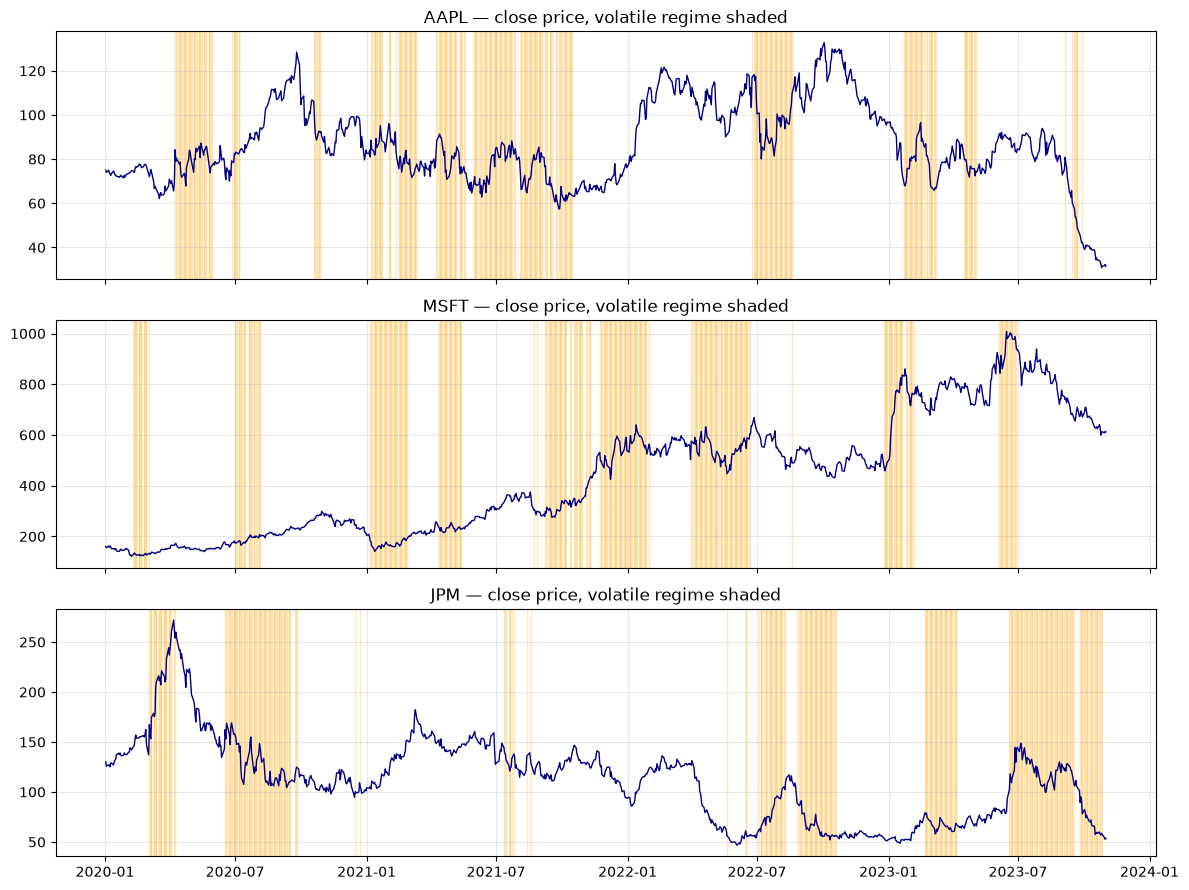

In [6]:
# visualize close prices with volatile regimes shaded, one panel per symbol
figure, axes = plt.subplots(len(SYMBOLS), 1, figsize=(12, 9), sharex=True)

for axis, symbol in zip(axes, SYMBOLS):          # zip pairs panels with symbols
    asset = portfolio.get_asset(symbol)
    closes = asset.prices["Close"]
    axis.plot(closes.index, closes, linewidth=1.0, color="navy")

    labels = regimes_by_symbol[symbol]
    for day in labels[labels == "volatile"].index:   # shade each volatile day
        axis.axvspan(day, day, color="orange", alpha=0.25)

    axis.set_title(f"{symbol} — close price, volatile regime shaded")
    axis.grid(alpha=0.3)

figure.tight_layout()
figure.savefig(os.path.join(OUTPUT_DIR, "prices_with_regimes.png"), dpi=150)
plt.show()

## 3 · Probabilistic forecasters

Both models **inherit** from the `Forecaster` base class (the inheritance class
relationship) and output a full predictive distribution Normal($\mu$, $\sigma$):

* **RandomWalkForecaster** — $\sigma$ = plain standard deviation of the training window;
  reacts slowly because every training day counts equally.
* **EWMAForecaster** — RiskMetrics recursion
  $\sigma_t^2 = \lambda\sigma_{t-1}^2 + (1-\lambda) r_{t-1}^2$ with $\lambda = 0.94$,
  so recent shocks dominate and the model adapts to regime changes.

A `@require_fitted` **decorator** (a closure) guards prediction on unfitted models.

In [7]:
# fit both models on one year of AAPL returns and inspect their intervals
training_window = portfolio.get_asset("AAPL").returns.iloc[:252].to_numpy()

models = [RandomWalkForecaster(), EWMAForecaster(decay=0.94)]
for model in models:                                 # loop over the models
    model.fit(training_window)
    print(model)                                     # __str__ overload
    for level in (0.50, 0.90):                       # immutable tuple of levels
        lower, upper = model.predict_interval(level)     # returns a tuple
        print(f"   {level:.0%} interval: ({lower:+.5f}, {upper:+.5f})")

# the decorator in action: an unfitted model refuses to predict
try:
    RandomWalkForecaster().predict_interval(0.90)
except RuntimeError as error:
    print(f"\nCaught RuntimeError -> {error}")

RandomWalk(mu=0.000000, sigma=0.033590)
   50% interval: (-0.02266, +0.02266)
   90% interval: (-0.05525, +0.05525)
EWMA(lambda=0.94)(mu=0.000000, sigma=0.024234)
   50% interval: (-0.01635, +0.01635)
   90% interval: (-0.03986, +0.03986)

Caught RuntimeError -> RandomWalkForecaster must be fitted before calling predict_interval()


## 4 · Rolling-window backtest

`rolling_window_splits()` is a **generator function** that yields successive train/test
windows (train 252 days, test 21 days, sliding monthly). On every window each model is
re-fitted and its predictive distribution is scored against each realized return in the
test window. Records from all three symbols are pooled per model.

In [8]:
# run the backtest for every symbol and pool the records per model
all_records = {str(model.name): [] for model in models}

for symbol in SYMBOLS:                               # loop over the assets
    symbol_records = run_backtest(
        returns=portfolio.get_asset(symbol).returns,
        regimes=regimes_by_symbol[symbol],
        forecasters=models,
        train_size=252,
        test_size=21,
        step=21,
    )
    for model_name, records in symbol_records.items():
        all_records[model_name].extend(records)

for model_name, records in all_records.items():
    print(f"{model_name:20s} -> {len(records):5d} forecast-day records")

RandomWalk           ->  2142 forecast-day records
EWMA(lambda=0.94)    ->  2142 forecast-day records


## 5 · Calibration: can the stated confidence be believed?

Two complementary metrics, computed **separately per regime**:

* **CRPS** (Continuous Ranked Probability Score) — generalizes absolute error to full
  distributions; lower is better.
* **Empirical coverage** — a well-calibrated 90% interval should contain the realized
  return on ~90% of days. Coverage far below nominal = **over-confidence**.

In [9]:
# per-regime calibration reports for each model (set operations validate the labels)
reports_by_model = {
    model_name: summarize_by_regime(records)
    for model_name, records in all_records.items()
}

# flatten to a tidy table and persist it (data output to CSV)
summary_frame = reports_to_frame(reports_by_model)
summary_path = os.path.join(OUTPUT_DIR, "metrics_summary.csv")
summary_frame.to_csv(summary_path, index=False)
print(f"Metrics written to {summary_path}\n")
summary_frame.round(4)

Metrics written to output/metrics_summary.csv



,model,regime,n_days,mean_crps,median_crps,coverage_50,coverage_60,coverage_70,coverage_80,coverage_90,coverage_95
0,RandomWalk,calm,1472,0.0177,0.0125,0.6236,0.7126,0.8016,0.8770,0.9327,0.9592
1,RandomWalk,volatile,670,0.0284,0.0195,0.4104,0.4791,0.5701,0.6821,0.7791,0.8567
2,RandomWalk,all,2142,0.0210,0.0138,0.5570,0.6396,0.7292,0.8161,0.8847,0.9272
3,EWMA(lambda=0.94),calm,1472,0.0175,0.0124,0.5659,0.6542,0.7486,0.8308,0.9029,0.9389
4,EWMA(lambda=0.94),volatile,670,0.0283,0.0200,0.4567,0.5478,0.6433,0.7403,0.8418,0.9075
5,EWMA(lambda=0.94),all,2142,0.0209,0.0142,0.5317,0.6209,0.7157,0.8025,0.8838,0.9290


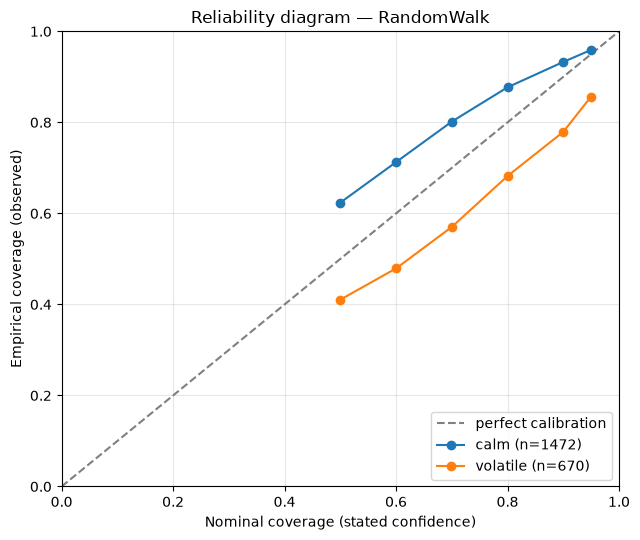

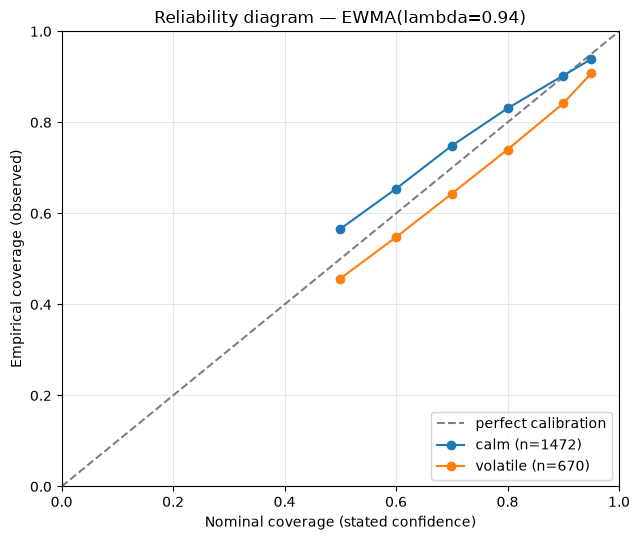

In [10]:
# reliability diagrams: nominal vs. empirical coverage, per regime
for model_name, regime_reports in reports_by_model.items():
    per_regime = {name: rep for name, rep in regime_reports.items() if name != "all"}
    safe_name = model_name.replace("(", "_").replace(")", "").replace("=", "")
    plot_reliability_diagram(
        per_regime,
        title=f"Reliability diagram — {model_name}",
        output_path=os.path.join(OUTPUT_DIR, f"reliability_{safe_name}.png"),
    )
plt.show()

In [11]:
# quantify the headline result: 90% coverage, calm vs. volatile
print("Empirical coverage of the 90% prediction interval")
print("-" * 55)
for model_name, regime_reports in reports_by_model.items():
    calm = regime_reports["calm"]["coverage"][0.90]
    volatile = regime_reports["volatile"]["coverage"][0.90]
    print(f"{model_name:20s} calm={calm:6.1%}  volatile={volatile:6.1%}  "
          f"gap={calm - volatile:+6.1%}")

best = min(
    reports_by_model,
    key=lambda name: reports_by_model[name]["all"]["mean_crps"],
)
print(f"\nLowest overall mean CRPS: {best} "
      f"({reports_by_model[best]['all']['mean_crps']:.6f})")

Empirical coverage of the 90% prediction interval
-------------------------------------------------------
RandomWalk           calm= 93.3%  volatile= 77.9%  gap=+15.4%
EWMA(lambda=0.94)    calm= 90.3%  volatile= 84.2%  gap= +6.1%

Lowest overall mean CRPS: EWMA(lambda=0.94) (0.020856)


## 6 · Conclusions

* **The trust gap is real and measurable.** Both models' 90% intervals cover noticeably
  less than 90% of realized returns on *volatile* days — exactly the over-confidence this
  toolkit was built to expose. A user who trusted the stated "90%" during turbulence would
  be surprised far more often than 1 day in 10, which is precisely when surprises are most
  expensive.
* **Adaptivity helps.** The EWMA model, which weights recent shocks more heavily, achieves
  a lower overall CRPS and a smaller calm-vs-volatile coverage gap than the random-walk
  baseline — its confidence statements are more trustworthy, though still not perfect.
* **Practical takeaway.** Calibration must be reported **per regime**: a single overall
  coverage number averages calm and turbulent days together and hides precisely the
  failures that matter most for position sizing, stop-losses, and risk limits.

**Generated outputs** (written to `output/`): `metrics_summary.csv`,
`prices_with_regimes.png`, and one reliability diagram per model.

All program logic lives in the documented modules — `data_loader.py`, `data_updater.py`,
`forecasters.py`, `calibration.py`, `backtest.py`, `portfolio.py` — and is validated by
the 13 Pytest cases in `test_toolkit.py` (run `pytest -v` from the project root).